                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
shape: (20, 11)
number of rows: 20
number of columns: 11

First 5 rows:
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   

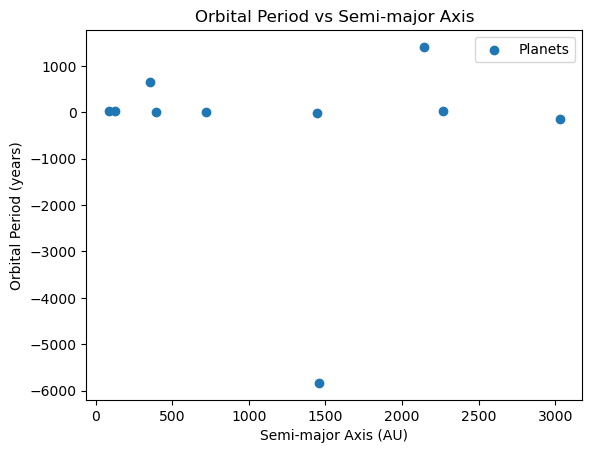

Fitted model: P = -0.00 * a^1.5
reduced chi-squared: -20546.58


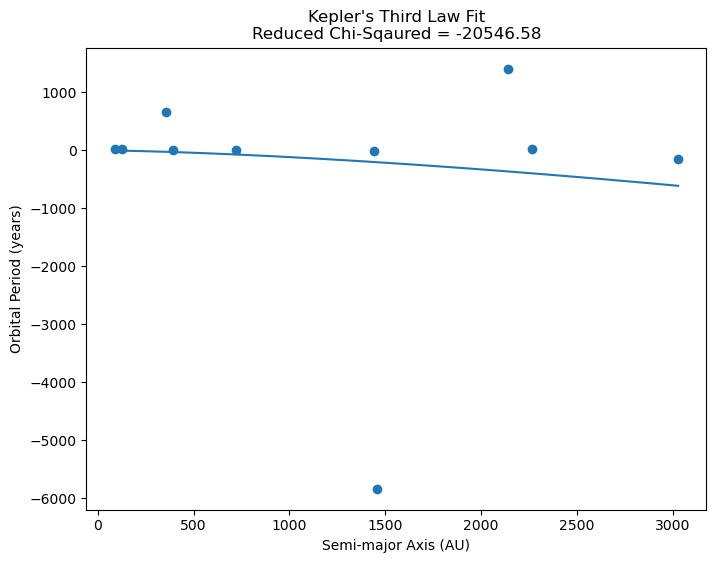

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

df = pd.read_csv('solar_system.csv')
print(df.head())

print("shape:", df.shape)
print("number of rows:", df.shape[0])
print("number of columns:", df.shape[1])
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())
print("\nColumn names:")
print(df.columns)
print("\nRow names (index):")
print(df.index)

print(df['Attribute'])
orbital_period = df.iloc[5, 1:].astype(float)
periphelion = df.iloc[6, 1:].astype(float)
aphelion = df.iloc[7, 1:].astype(float)
print("orbital period:")
print(orbital_period)
print("\nPeriphelion")
print(periphelion)
print("\aphelion")
print(aphelion)

print("Periphelion means the closest distance between a planet and its sun")
print("Aphelion means the farthest distance between a planet and its sun")
print("Semi-major axis means the average distance from the planet to the sun")

semi_major_axis = (periphelion + aphelion) / 2
print("Semi major axis:", semi_major_axis)

semi_major_series = pd.Series(
    ["Semi major axis (AU)"] + list(semi_major_axis),
    index=df.columns
)
df = pd.concat([df, semi_major_series.to_frame().T], ignore_index=True)

print("New shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

plt.figure()
plt.scatter(semi_major_axis, orbital_period, label="Planets")
plt.xlabel("Semi-major Axis (AU)")
plt.ylabel("Orbital Period (years)")
plt.title("Orbital Period vs Semi-major Axis")
plt.legend()
plt.show()

def keplers_third_law(a, m):
    return m * a**1.5

params, convariance = curve_fit(keplers_third_law, semi_major_axis, orbital_period)

m_fit = params[0]

print(f"Fitted model: P = {m_fit:.2f} * a^1.5")

predicted_period = keplers_third_law(semi_major_axis, m_fit)
chi_squared = np.sum((orbital_period - predicted_period)**2 / predicted_period)
dof = len(orbital_period) - 1 
reduced_chi_squared = chi_squared / dof
print(f"reduced chi-squared: {reduced_chi_squared:.2f}")

a_fit = np.linspace(semi_major_axis.min(), semi_major_axis.max(), 200)
p_fit = keplers_third_law(a_fit, m_fit)

plt.figure(figsize=(8,6))
plt.scatter(semi_major_axis, orbital_period, label="Data")
plt.plot(a_fit, p_fit, label=f"Fit: P = {m_fit:.2f}a^1.5")
plt.xlabel("Semi-major Axis (AU)")
plt.ylabel("Orbital Period (years)")
plt.title(f"Kepler's Third Law Fit\nReduced Chi-Sqaured = {reduced_chi_squared:.2f}")
plt.legend
plt.show()

df.to_csv("kepler.csv", index=False)
